# HSST B10m 2026: Llama 3.2 transformer exercise
#### Notice
Built with Llama. Llama 3.2 is licensed under the Llama 3.2 Community License, Copyright © Meta Platforms, Inc. All Rights Reserved.
# About this notebook
In the previous notebook (hsst-picogpt-binder) we examined the basic internal anatomy of the large language model GPT-2 (124 million parameters), one of the earliest models developed by OpenAI in 2019.

This notebook has similar aims but uses Llama-3.2-1B, a larger (1.23 billion parameters) and more modern model, released by Meta in 2024. This is a open-weights model whose use is subject to a [licence](https://www.llama.com/llama3_2/license/) and [usage policy](https://www.llama.com/llama3_2/use-policy/). The fundamentals of the model architecture remain similar to GPT-2 with some refinements as illustrated in [this supplementary material](https://github.com/rasbt/LLMs-from-scratch/blob/main/ch05/07_gpt_to_llama/converting-llama2-to-llama3.ipynb) to Sebastian Raschka's book 'Build a Large Language Model From Scratch'. Llama-3.2-1B is very small compared to some models used by services like ChatGPT, Claude etc., which might have trillions parameters.

The GPT-2 version of this notebook used an incredibly lightweight function (~60 lines of numpy code) from [picoGPT](https://github.com/jaymody/picoGPT) to run the model. Similar projects exist for the Llama architecture. However, this notebook takes advantage of the much larger and more general [llama-cpp-python](http://github.com/abetlen/llama-cpp-python) package (Python bindings for the [llama.cpp](https://github.com/ggml-org/llama.cpp) project) so that quantisation can be used to fit the model into a small memory footprint for use in a Binder environment, and to allow for future extensions. It was still necessary to write a wrapper (LlamaWrapper) to open and close parts of the model as required to avoid exceeding the 2GB RAM limit of mybinder.org servers; this means all llm statements must be run within a 'with' statement.

Daniel Warren\
May 2026

In [ ]:
from llama_wrapper import LlamaWrapper

MODEL_FILE = "models/Llama-3.2-1B.Q4_0.gguf" # Base model, without instruction-tuning
MODEL_IT_FILE = "models/Llama-3.2-1B-Instruct.Q4_0.gguf" # With instruction-tuning

llm_full = LlamaWrapper(MODEL_FILE)
llm_full_it = LlamaWrapper(MODEL_IT_FILE,chat_format="llama-3")
llm_tokenizer_only = LlamaWrapper(MODEL_FILE,tokenizer_only=True)

## 1 Text completion
Start by running the code below (making changes if you want) to complete a text sequence.

Two versions of the model are available. The base model, without instruction-tuning, is only trained to complete arbitrary text. The version with instruction-tuning has been trained to respond to queries/tasks like a ChatGPT-style assistant.

Change the subject of the `with` statement to `llm_full_it` to compare the two versions of the model.

In [3]:
from ipywidgets import HTML

with llm_full_it as llm:
    prompts = ["The director of the film Titanic was",
               "Water boils at",
               "How many items are there in a dozen?",
               "The uses of artificial intelligence in medical physics include"]
    
    for (i,prompt) in enumerate(prompts):
        completion = llm.create_completion(prompt=prompt,max_tokens=20,temperature=0)['choices'][0]['text']
        display(HTML(f'<pre><span style="color:red">{prompt}</span><span style="color:blue">{completion}</span>...</pre>'))

llama_context: n_ctx_seq (512) < n_ctx_train (131072) -- the full capacity of the model will not be utilized


HTML(value='<pre><span style="color:red">The director of the film Titanic was</span><span style="color:blue"> …

HTML(value='<pre><span style="color:red">Water boils at</span><span style="color:blue"> 100 degrees Fahrenheit…

HTML(value='<pre><span style="color:red">How many items are there in a dozen?</span><span style="color:blue"> …

HTML(value='<pre><span style="color:red">The uses of artificial intelligence in medical physics include</span>…

## 2 Tokenizer
The first part of the inference process is tokenization - converting the input text string into a sequence of numbers representing word parts.

Run the code below (making changes if you want) to see how the tokenizer splits up various strings. This example is intended to illustrate why simple LLMs are not good at counting letters in words. Can you see why?

In [4]:
# Tokenizer examples
prompts = ["strawberry","blueberry","How many r's in strawberry?"]
all_tokens = set()
with llm_tokenizer_only as llm:
    print ("TOKENIZATION EXAMPLES:")
    for prompt in prompts:
        tokens = llm.tokenize(prompt.encode(),add_bos=False)
        print(f"'{prompt}' tokenizes to {tokens}")
        all_tokens = all_tokens.union(tokens)
    
    token_mapping = {t:llm.detokenize([t]).decode() for t in sorted(all_tokens)}

print ("\nTOKEN MAPPINGS:")
for (k,v) in token_mapping.items():
    print(f"{k}: '{v}'")

llama_context: n_ctx_seq (512) < n_ctx_train (131072) -- the full capacity of the model will not be utilized


TOKENIZATION EXAMPLES:
'strawberry' tokenizes to [496, 675, 15717]
'blueberry' tokenizes to [12481, 15717]
'How many r's in strawberry?' tokenizes to [4438, 1690, 436, 596, 304, 73700, 30]

TOKEN MAPPINGS:
30: '?'
304: ' in'
436: ' r'
496: 'str'
596: ''s'
675: 'aw'
1690: ' many'
4438: 'How'
12481: 'blue'
15717: 'berry'
73700: ' strawberry'


## 3 Hyper-parameters
The code below displays the metadata of the model, which includes some key  hyperparameters:
* **llama.vocab_size** is the size of the tokenizer's vocabulary (the number of word/text parts that have been assigned a unique token ID)
* **llama.context_length** is the size of the context (the maximum length of text that was used in training, in units of tokens)
  - Because this model uses RoPE (rotational positioning embedding), it can still produce completions for text longer than the context size used in training.
* **llama.embedding_length** is the size of the embedding (the number of directions in the arbitrary, learned, coordinate-system (or 'latent space') that the model uses to represent token meaning and relative position)
* **llama.attention_head_count** is the number of attention heads per layer (the attention mechanism is applied in parallel N times on different linear transformations of the embeddings, with those transformations being learned parameters)
* **llama.block_count** is the number of attention blocks in the network

In [5]:
with llm_full as llm:
    hparams = llm.metadata

print ("NETWORK HYPERPARAMETERS:")
for (k,v) in sorted(hparams.items()):
    print(f"{k}: '{v}'")

llama_context: n_ctx_seq (512) < n_ctx_train (131072) -- the full capacity of the model will not be utilized


NETWORK HYPERPARAMETERS:
general.architecture: 'llama'
general.file_type: '2'
general.license: 'llama3.2'
general.name: 'Models'
general.quantization_version: '2'
general.size_label: '1.2B'
general.type: 'model'
llama.attention.head_count: '32'
llama.attention.head_count_kv: '8'
llama.attention.key_length: '64'
llama.attention.layer_norm_rms_epsilon: '0.000010'
llama.attention.value_length: '64'
llama.block_count: '16'
llama.context_length: '131072'
llama.embedding_length: '2048'
llama.feed_forward_length: '8192'
llama.rope.dimension_count: '64'
llama.rope.freq_base: '500000.000000'
llama.vocab_size: '128256'
tokenizer.ggml.bos_token_id: '128000'
tokenizer.ggml.eos_token_id: '128001'
tokenizer.ggml.model: 'gpt2'
tokenizer.ggml.pre: 'llama-bpe'


## 4 Parameters/weights
The learned parameters ('weights') of the model are the results of the training process.
### 4.1 Token Embedding
* **token_embd.weight** is the token embedding matrix, mapping each token in the vocabulary to a vector of length n_embd - a multi-dimensional 'latent space'

llama_context: n_ctx_seq (512) < n_ctx_train (131072) -- the full capacity of the model will not be utilized


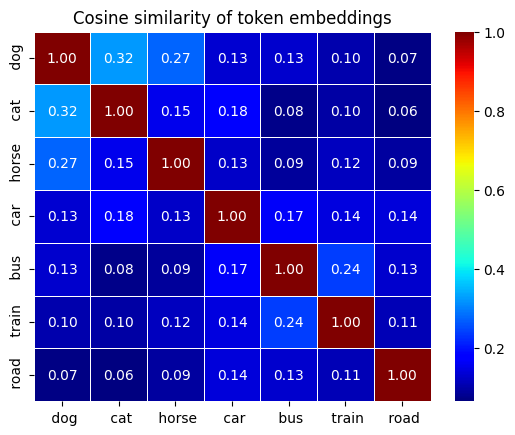

In [7]:
import numpy as np
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt
from gguf.quants import dequantize

# mybinder.org doesn't have enough memory to dequantize the whole matrix, so will only dequantize relevant rows within the loop
(wte_q_data,wte_q_type) = llm_full.get_tensor("token_embd.weight")

prompts = [" dog"," cat"," horse"," car"," bus"," train"," road"]
with llm_tokenizer_only as llm:
    token_a_list = [llm.tokenize(prompt_a.encode(),add_bos=False) for prompt_a in prompts]
    token_b_list = [llm.tokenize(prompt_b.encode(),add_bos=False) for prompt_b in prompts]

x_vals = []
y_vals = []

rows = {}

for (i,prompt_a) in enumerate(prompts):
    for (j,prompt_b) in enumerate(prompts):
            (token_a,token_b) = (token_a_list[i],token_b_list[j])
            # Note that these will only take the first token if the input encodes to multiple token
            
            if (len(token_a) > 1) or (len(token_b) > 1):
                print("WARNING: One or more prompts contains >1 token. Only first token will be used.")
            token_a_embedding = dequantize(wte_q_data[token_a[0],:],wte_q_type)
            token_b_embedding = dequantize(wte_q_data[token_b[0],:],wte_q_type)

            similarity = np.dot(token_a_embedding/np.sqrt(np.sum(token_a_embedding**2)),
                                token_b_embedding/np.sqrt(np.sum(token_b_embedding**2)))

            if prompt_a not in rows.keys():
                rows[prompt_a] = pd.Series(index=[prompt_a])
            rows[prompt_a][prompt_b] = similarity

df = pd.DataFrame([rows[prompt_a] for prompt_a in prompts],index=prompts)

ax = plt.axes()
sns.heatmap(df, annot=True, fmt=".2f", linewidths=.5,cmap="jet",ax=ax)
plt.title("Cosine similarity of token embeddings")
plt.show(ax)

### 4.2 Position Embedding
Llama models don't use an explicit position embedding matrix like GPT models. Instead they calculate a relative position embedding for query and key values in the attention calculation, using a method called RoPE (Rotary Positional Embedding).

This notebook doesn't currently include a visualization of position embedding for Llama 3.2.

### 4.3 Transformer blocks
Run the code block below to view the structure of the parameters for the transformer blocks.

In [8]:
for t in sorted(llm.get_tensors()):
    print(f"{t.name}: array with shape {t.shape}")

blk.0.attn_k.weight: array with shape [2048  512]
blk.0.attn_norm.weight: array with shape [2048]
blk.0.attn_output.weight: array with shape [2048 2048]
blk.0.attn_q.weight: array with shape [2048 2048]
blk.0.attn_v.weight: array with shape [2048  512]
blk.0.ffn_down.weight: array with shape [8192 2048]
blk.0.ffn_gate.weight: array with shape [2048 8192]
blk.0.ffn_norm.weight: array with shape [2048]
blk.0.ffn_up.weight: array with shape [2048 8192]
blk.1.attn_k.weight: array with shape [2048  512]
blk.1.attn_norm.weight: array with shape [2048]
blk.1.attn_output.weight: array with shape [2048 2048]
blk.1.attn_q.weight: array with shape [2048 2048]
blk.1.attn_v.weight: array with shape [2048  512]
blk.1.ffn_down.weight: array with shape [8192 2048]
blk.1.ffn_gate.weight: array with shape [2048 8192]
blk.1.ffn_norm.weight: array with shape [2048]
blk.1.ffn_up.weight: array with shape [2048 8192]
blk.10.attn_k.weight: array with shape [2048  512]
blk.10.attn_norm.weight: array with shape

## 5 Outputs
The output of the model is a likelihood score for every possible token in the vocabulary.

Vary the prompt below to see how it changes the highest-scoring predicted tokens.

In [ ]:
from collections import OrderedDict

prompt = "The cat sat on the"

with llm_full as llm:
    tokens = llm.tokenize(prompt.encode())
    llm.reset()
    llm.eval(tokens)
    next_token_scores = llm._scores[-1]
    
    wordparts_and_scores = [(llm.detokenize([i]).decode('charmap'),score) for (i,score) in enumerate(next_token_scores)]
    wordparts_and_scores = sorted(wordparts_and_scores,key=lambda x:x[1],reverse=True) # sort by score
    
    top5_wordparts_and_scores = wordparts_and_scores[:5]
    bottom5_wordparts_and_scores = reversed(wordparts_and_scores[-5:])
    
    print(f"Top 5 predictions to complete '{llm.detokenize(tokens).decode()}':")
    for (i,(word,score)) in enumerate(top5_wordparts_and_scores):
        softmax_probability = np.exp(score)/np.sum(np.exp(next_token_scores))
        print(f"{i+1}. {word} (score = {score:.2f}, softmax probability = {softmax_probability:.2f})")
        
    print(f"\nBottom 5 predictions to complete '{llm.detokenize(tokens).decode()}':")
    for (i,(word,score)) in enumerate(bottom5_wordparts_and_scores):
        softmax_probability = np.exp(score)/np.sum(np.exp(next_token_scores))
        print(f"{i+1}. {word} (score = {score:.2f}, softmax probability = {softmax_probability:.2f})")

## 6 Sampling

Because the forward-pass of the model can be mapped to a probability of any given token occuring, text can be generated by sampling the probability distribution. The distribution can be modified using a parameter known as 'temperature' (an inverse factor applied to the likelihood scores prior to softmax) to bias the random sampler towards less-likely or more-likely tokens. `temperature = 0` corresponds to always selecting the most likely token (which is deterministic); `temperature = 1` keeps the distribution unmodified, `temperature > 1` will increase the probability of less-likely tokens being sampled (sometimes considered to boost the 'creativity' of the output). Other samplers also exist which might use the temperature parameter differently and/or have different sample parameters.

Examine the effect of changing the temperature below.

In [ ]:
from ipywidgets import HTML

temperature = 1.0
prompt = "The seven colours of the rainbow are"

with llm_full_it as llm:
    for i in range(5):
        completion = llm.create_completion(prompt=prompt,max_tokens=20,temperature=temperature)['choices'][0]['text']
        display(HTML(f'<pre><strong>Repeat {i+1}: </strong><span style="color:red">{prompt}</span><span style="color:blue">{completion}</span>...</pre>'))

llama_context: n_ctx_seq (512) < n_ctx_train (131072) -- the full capacity of the model will not be utilized


HTML(value='<pre><strong>Repeat 1: </strong><span style="color:red">The seven colours of the rainbow are</span…

HTML(value='<pre><strong>Repeat 2: </strong><span style="color:red">The seven colours of the rainbow are</span…

HTML(value='<pre><strong>Repeat 3: </strong><span style="color:red">The seven colours of the rainbow are</span…

HTML(value='<pre><strong>Repeat 4: </strong><span style="color:red">The seven colours of the rainbow are</span…